Simulation Complete. Total Simulated Energy Consumed: 54.98 Joules


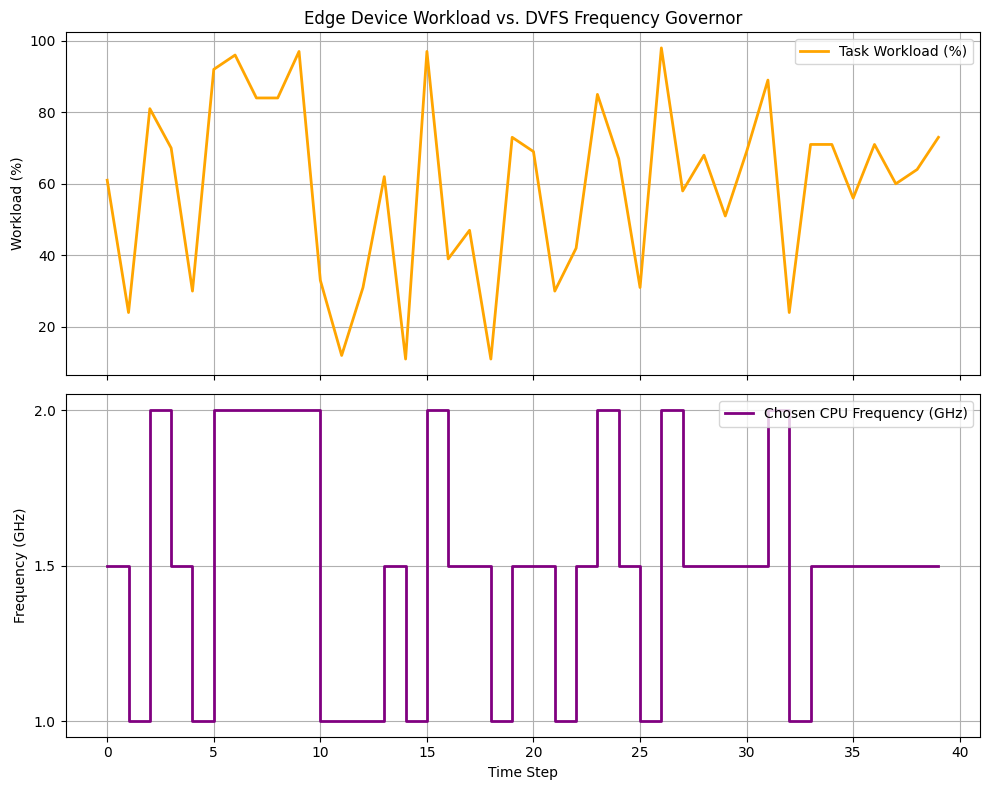

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def run_dvfs_simulation():
    np.random.seed(42)
    steps = 40
    workload = np.random.randint(10, 100, size=steps) # Incoming tasks (%)

    frequencies = np.array([1.0, 1.5, 2.0])  # GHz
    voltages = np.array([0.9, 1.1, 1.3])     # Volts (Power proportional to V^2 * f)

    chosen_freqs = []
    energy_consumed = []

    for load in workload:
        # Simple policy-driven governor logic: scale frequency with workload intensity
        if load < 35:
            freq_idx = 0  # Low power mode
        elif load < 75:
            freq_idx = 1  # Medium power mode
        else:
            freq_idx = 2  # High performance mode

        f = frequencies[freq_idx]
        v = voltages[freq_idx]

        # Dynamic power consumption estimation: P = V^2 * f scaled by workload ratio
        power = (v ** 2) * f * (load / 100.0)
        chosen_freqs.append(f)
        energy_consumed.append(power)

    total_energy = sum(energy_consumed)
    print(f"Simulation Complete. Total Simulated Energy Consumed: {total_energy:.2f} Joules")

    # Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    ax1.plot(workload, label='Task Workload (%)', color='orange', linewidth=2)
    ax1.set_title('Edge Device Workload vs. DVFS Frequency Governor')
    ax1.set_ylabel('Workload (%)')
    ax1.legend(loc='upper right')
    ax1.grid(True)

    ax2.plot(chosen_freqs, label='Chosen CPU Frequency (GHz)', color='purple', drawstyle='steps-post', linewidth=2)
    ax2.set_ylabel('Frequency (GHz)')
    ax2.set_xlabel('Time Step')
    ax2.set_yticks([1.0, 1.5, 2.0])
    ax2.legend(loc='upper right')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_dvfs_simulation()